In [1]:
from cobaya import get_model

In [2]:
params = {'logA': 3.044,
 'n_s': 0.965,
 'h': 0.675,
 'omega_b': 0.02235,
 'omega_cdm': 0.120,
 'tau_reio': 0.0543,
         }

mode=get_model('class_lensingTT.yaml')
mode.logposterior(params)

[model] *WARNING* Ignored blocks/options: ['sampler', 'output']
[classy] `classy` module loaded successfully from /Users/zhiyulu/Install/anaconda3/lib/python3.11/site-packages/classy-3.2.3-py3.11-macosx-11.0-arm64.egg
ISWlensing: tt tp pp Nbins  98 98 98
ISWlensing: lmins  2 2 2
ISWlensing: lmaxs  99 99 99
ISWlensing: OK for resp calc
ISWlensing: Rfid test ok
ISWlensing: rebinning using inverse covariance weighting  83 7 2


LogPosterior(logpost=1.6476756247383055, logpriors=[2.7894037928589683], loglikes=array([-1.14172817]), derived=[2.0989031673191437e-09, 0.31384172488986367, 0.14299413590294416, 0.6860787971858595, 0.2453874077290285, 7.6847991943359375, 0.8112617288974895, 0.9874363310173238, 0.4544816256624392, 0.6072096420405823, 2.098903167319144, 1.8829033242359754, 13.785194919782512, 147.11897604043983], finite=False)

In [3]:
params = {'logA': 3.044,
 'ns': 0.965,
 'H0':67.5,
 'ombh2': 0.02235,
 'omch2': 0.120,
 'tau': 0.0543,
         }

mode=get_model('camb_lensingTT.yaml')
mode.logposterior(params)

[model] *WARNING* Ignored blocks/options: ['sampler', 'output']
[camb] `camb` module loaded successfully from /Users/zhiyulu/Install/anaconda3/lib/python3.11/site-packages/camb
ISWlensing: tt tp pp Nbins  98 98 98
ISWlensing: lmins  2 2 2
ISWlensing: lmaxs  99 99 99
ISWlensing: OK for resp calc
ISWlensing: Rfid test ok
ISWlensing: rebinning using inverse covariance weighting  83 7 2


LogPosterior(logpost=-3.0439793135805306, logpriors=[-1.9211269087869498], loglikes=array([-1.1228524]), derived=[2.0989031673191437e-09, 0.31384332855006886, 0.14299486657062513, 0.6860773554624547, 0.2458739140261756, 0.24720564088785, 2.4525227716281934, 7.68826106985445, 0.8115160114539416, 0.9877458338887658, 0.45462524027582213, 0.6074007422574697, 2.098903167319144, 1.8829033242359754, 13.784896588248458, 147.11341777496776], finite=False)

In [4]:
(1.1416-1.122)/1.122

0.01746880570409968

In [5]:
import numpy as np
loaded_data = np.load('camb_cls.npz')
camb_cls = {key: loaded_data[key] for key in loaded_data.files}
loaded_data = np.load('class_cls.npz')
class_cls = {key: loaded_data[key] for key in loaded_data.files}

In [6]:
camb_cls['pt']-camb_cls['tp']

array([0., 0., 0., ..., 0., 0., 0.])

In [ ]:
# class raw_cl---> lensed_cl
# camb lensed_cl

(0.99, 1.1)

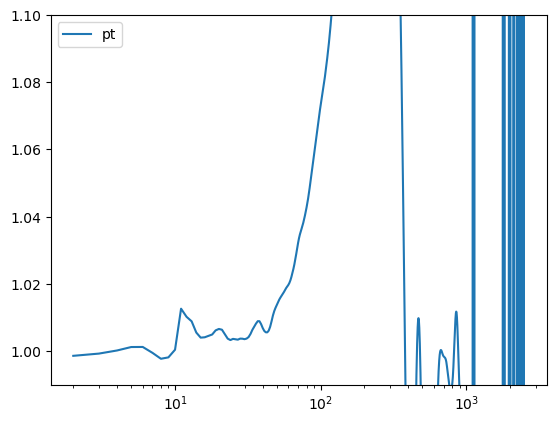

In [15]:
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
for k in class_cls.keys():
    if k=='ell': continue
    if k in ['tt','ee','pp','bb','te','tp']: continue
    iclass = interp1d(class_cls['ell'],class_cls[k])
    icamb = interp1d(camb_cls['ell'],camb_cls[k])
    ell = class_cls['ell'][2:]
    plt.plot(ell,iclass(ell)/icamb(ell),label=k)
plt.legend()
plt.semilogx()
plt.ylim(0.99,1.1)

(0.99, 1.1)

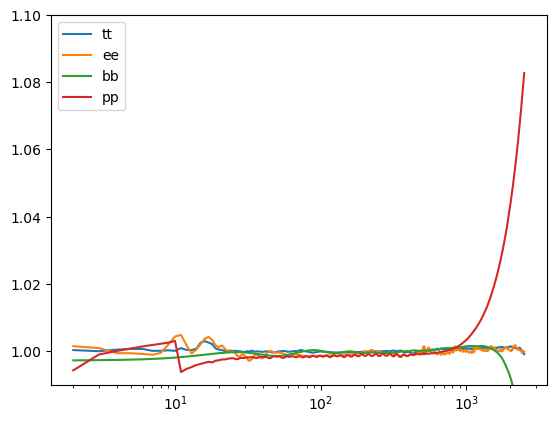

In [18]:
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
for k in class_cls.keys():
    if k=='ell': continue
    if k in ['pt','tp','te']: continue
    iclass = interp1d(class_cls['ell'],class_cls[k])
    icamb = interp1d(camb_cls['ell'],camb_cls[k])
    ell = class_cls['ell'][2:]
    plt.plot(ell,iclass(ell)/icamb(ell),label=k)
plt.legend()
plt.semilogx()
plt.ylim(0.99,1.1)